In [46]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, json, gc, math
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.Plotter.index import Plotter
from Network.index import ModelNetwork
from utils.index import *

In [47]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.7.1+cu118
True
NVIDIA GeForce RTX 4060


# HISTÓRICO DE TREINAMENTO

In [48]:
df = []

for bakup in os.listdir('Backup/'):
    path = f'Backup/{bakup}/info.json'

    with open(path, 'r', encoding='utf-8') as file:
        file = json.loads(file.read())

    info = {}
    for key, value in file.items():
        info.update(value)

    info['id'] = int(info.get('path').split('_')[-1])
    df.append(info)


df = pd.DataFrame(df).sort_values(by='id')
df

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,encoder,weights,network,img_size,lr,dropout,num_filters,n_images,classes,channels,mean,id
10,model_1,dice_focal,cosine,100,2,0.776262,0.795779,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.795779,1
6,model_2,dice_focal,plateau,100,2,0.785129,0.796063,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.796063,2
23,model_3,dice_focal,cosine,100,2,0.712353,0.747728,resnet34,imagenet,vnet,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.747728,3
19,model_4,dice,cosine,100,2,0.779273,0.798698,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.798698,4
4,model_5,dice_bce,cosine,100,2,0.780182,0.795342,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.795342,5
13,model_6,dice_focal,plateau,100,2,0.771641,0.789294,resnet34,imagenet,standard,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.789294,6
17,model_7,dice_focal,plateau,100,2,0.000000,0.000000,resnet34,imagenet,resaceunet,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.000000,7
18,model_8,dice_focal,plateau,100,2,0.759917,0.776250,resnet34,imagenet,resaceunet2,"[128, 128, 128]",0.0005,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.776250,8
9,model_9,dice_focal,plateau,100,2,0.000000,0.000000,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0050,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.000000,9
11,model_10,dice_focal,plateau,100,2,0.777393,0.793865,resnet34,imagenet,segresnet,"[128, 128, 128]",0.0010,0.10,16,"{'total': 220, 'train': 200, 'val': 10, 'test'...",1,1,0.793865,10


target: loss | fixed: {'network': 'segresnet', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'cosine', 'num_filters': 16, 'dropout': 0.1}


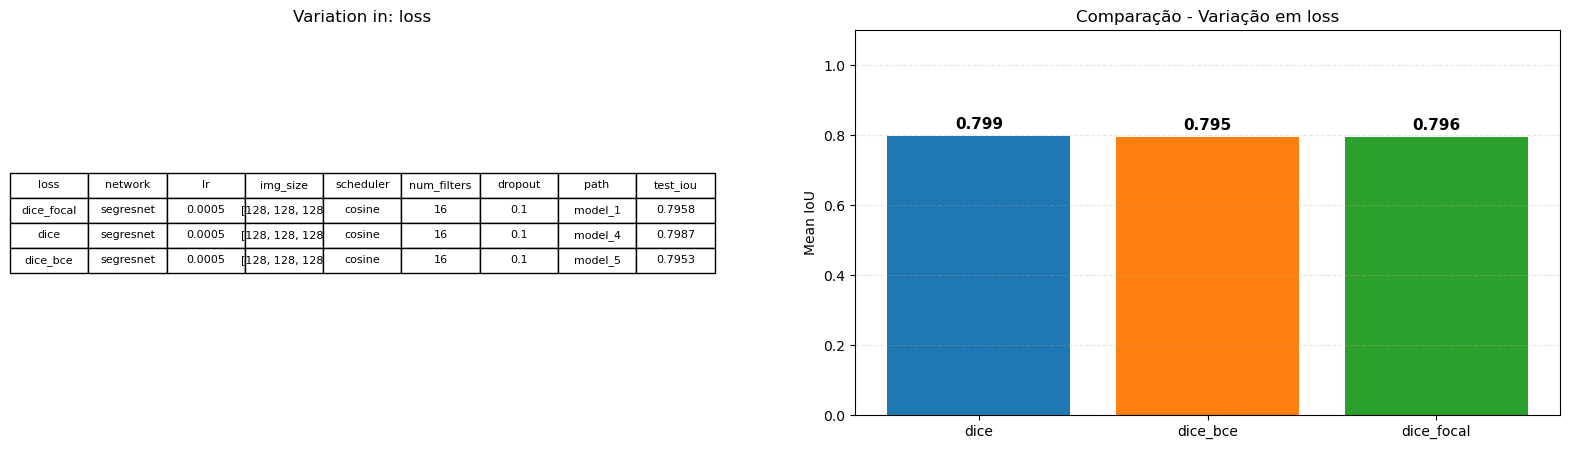

target: network | fixed: {'loss': 'dice_focal', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'cosine', 'num_filters': 16, 'dropout': 0.1}


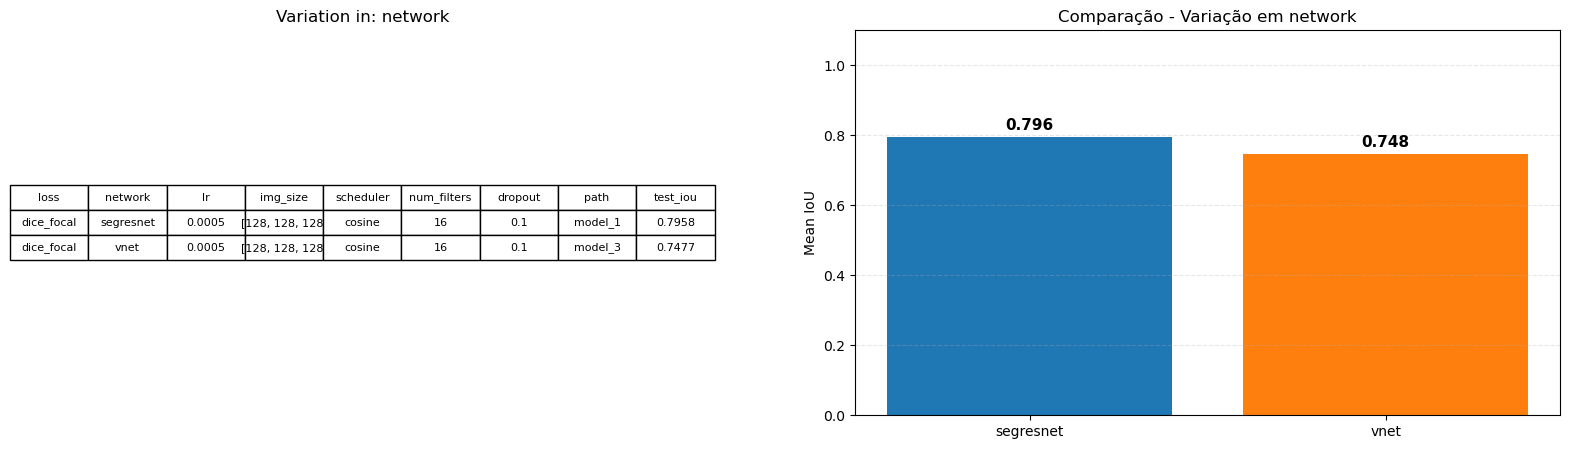

target: network | fixed: {'loss': 'dice_focal', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16, 'dropout': 0.1}


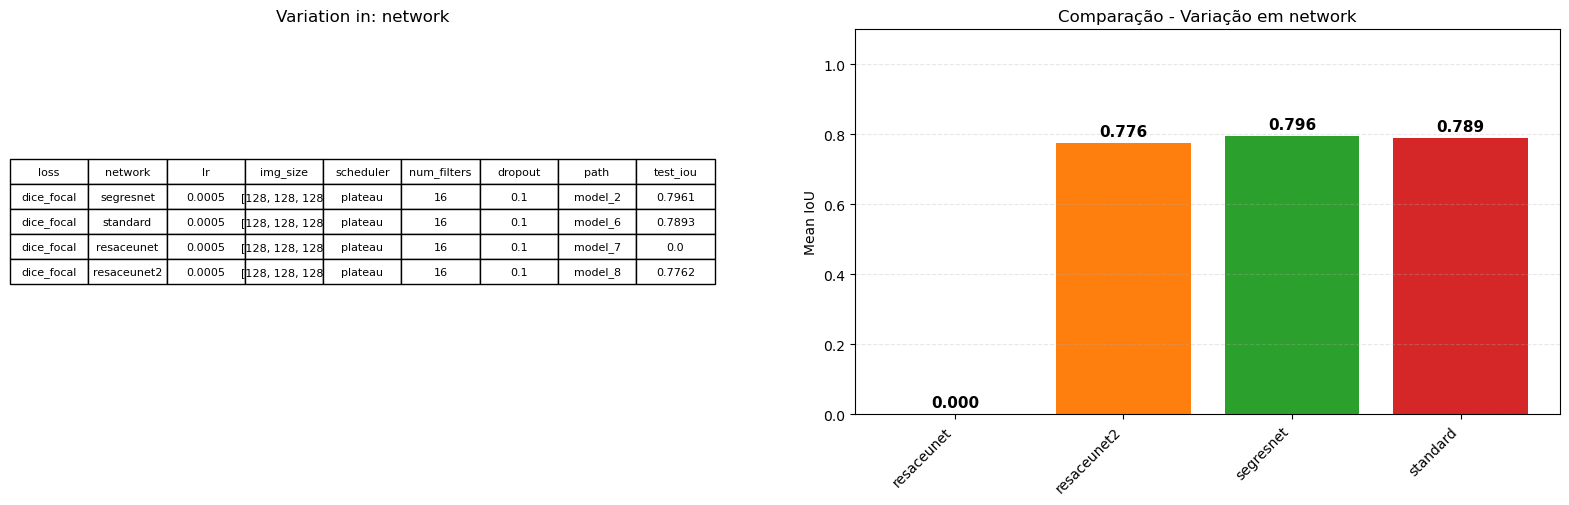

target: lr | fixed: {'loss': 'dice_focal', 'network': 'segresnet', 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16, 'dropout': 0.1}


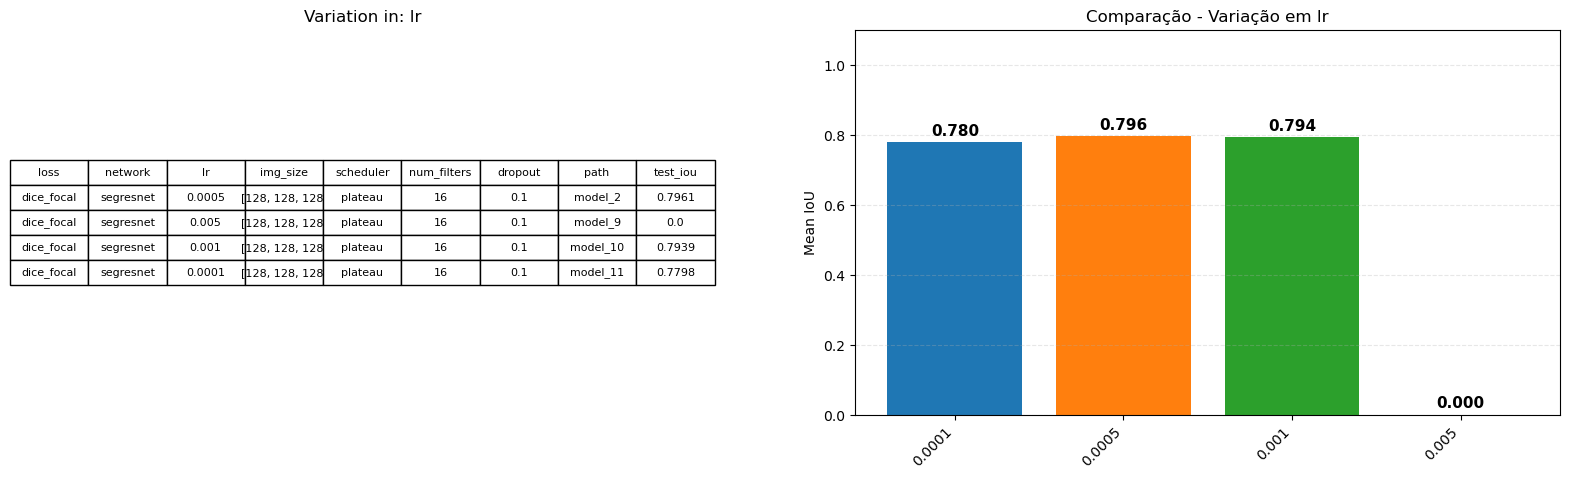

target: img_size | fixed: {'loss': 'dice_focal', 'network': 'resaceunet2', 'lr': 0.0005, 'scheduler': 'plateau', 'num_filters': 16, 'dropout': 0.1}


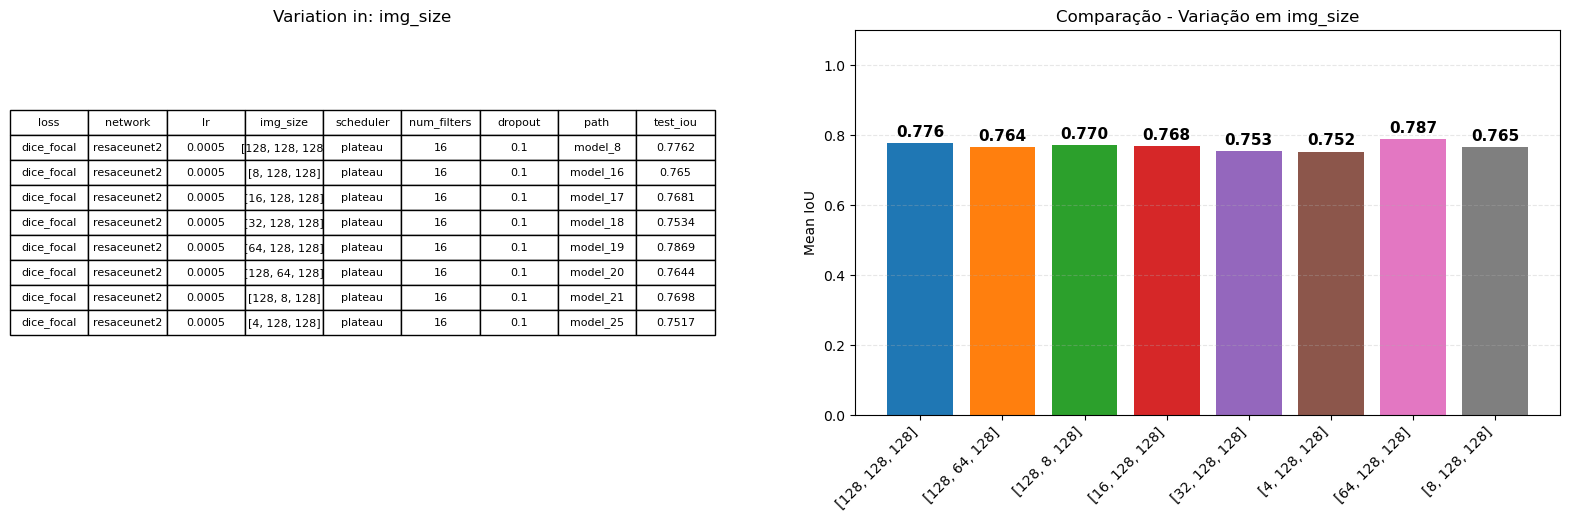

target: scheduler | fixed: {'loss': 'dice_focal', 'network': 'segresnet', 'lr': 0.0005, 'img_size': '[128, 128, 128]', 'num_filters': 16, 'dropout': 0.1}


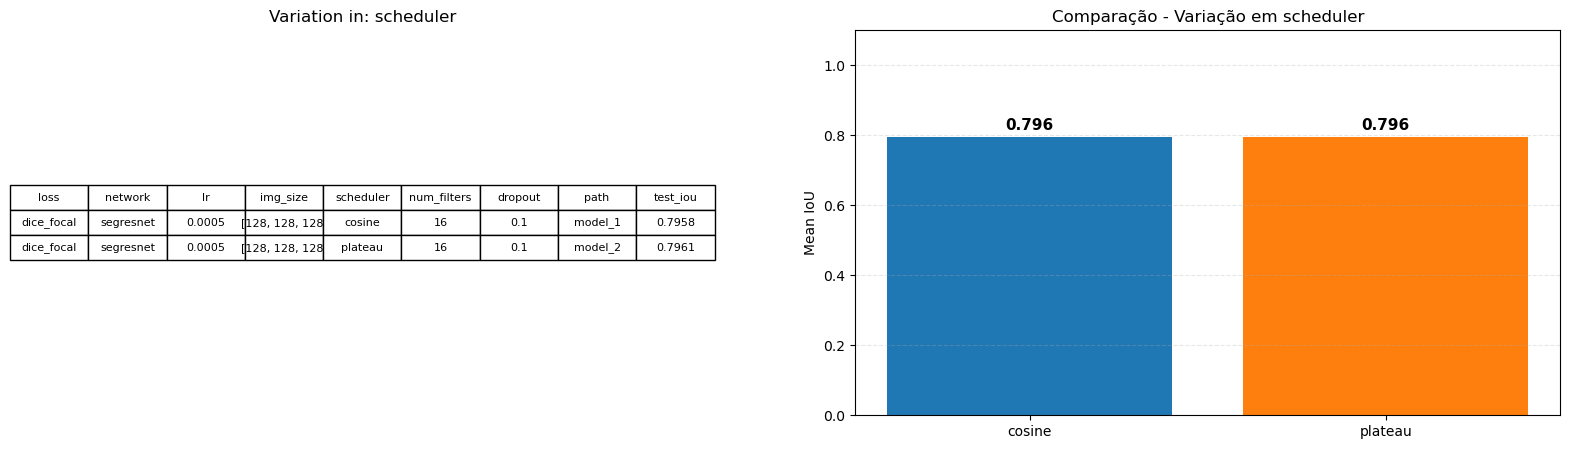

target: num_filters | fixed: {'loss': 'dice_focal', 'network': 'segresnet', 'lr': 0.0001, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'dropout': 0.1}


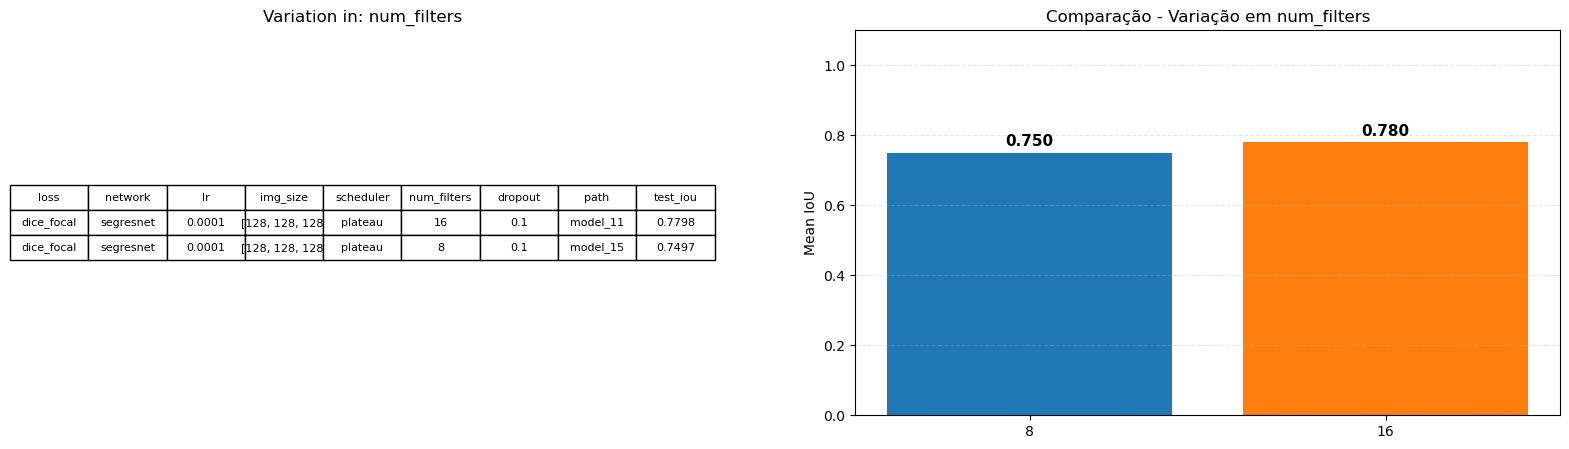

target: dropout | fixed: {'loss': 'dice_focal', 'network': 'segresnet', 'lr': 0.0001, 'img_size': '[128, 128, 128]', 'scheduler': 'plateau', 'num_filters': 16}


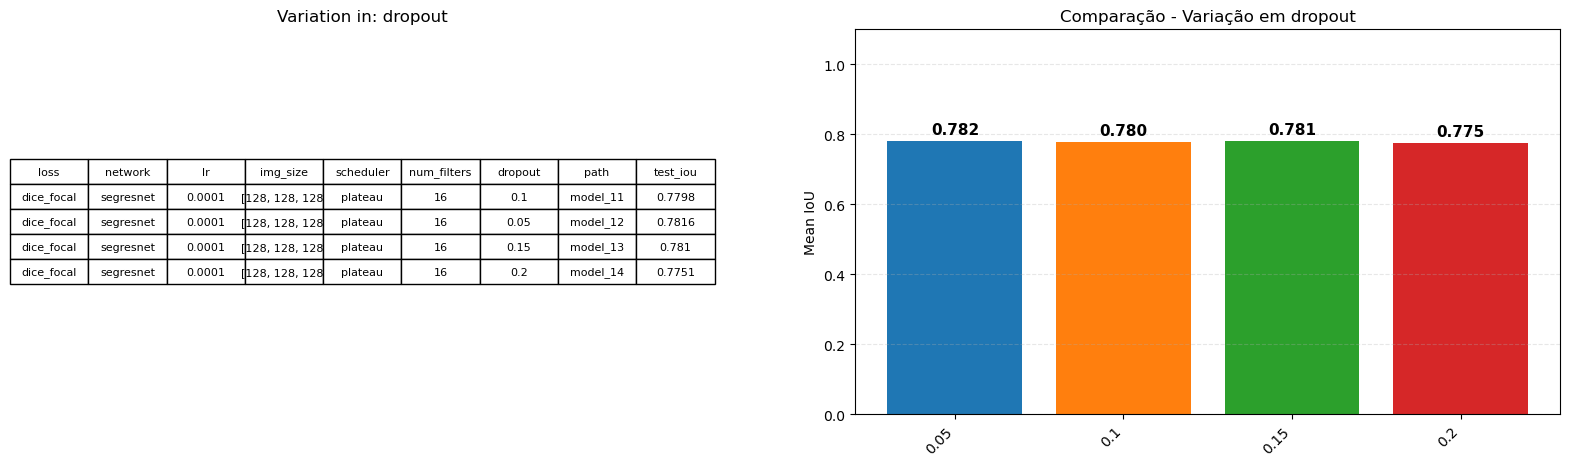

In [50]:
class VariationAnalysis:
    def __init__(self, df, variations, id=None, metric='test_iou'):
        self.df = df.copy()
        self.variations = [v for v in variations if v in self.df.columns]
        self.id = id
        self.metric = metric
        str_cols    = self.df.select_dtypes(include=['object']).columns
        self.df[str_cols] = self.df[str_cols].astype(str)

    def getSorted(self, df_group, variation):
        df_agg = df_group.groupby(variation, as_index=False)[self.metric].max()
        
        numeric_col = pd.to_numeric(df_agg[variation], errors='coerce')
        if numeric_col.notna().all():
            df_agg['__sort'] = numeric_col
            df_agg = df_agg.sort_values('__sort').drop(columns=['__sort'])
        else:
            df_agg = df_agg.sort_values(variation)
            
        return dict(zip(df_agg[variation], df_agg[self.metric]))

    def plot(self):
        for var in self.variations:
            fixed_cols = [c for c in self.variations if c != var]
            grouped    = self.df.groupby(fixed_cols) if fixed_cols else [(None, self.df)]
            
            for _, group in grouped:
                if group[var].nunique() <= 1:
                    continue
                    
                fixed_dict = group.iloc[0][fixed_cols].to_dict() if fixed_cols else {}
                print(f"target: {var} | fixed: {fixed_dict}")
                
                ref      = [self.id] if self.id else []
                df_table = group[self.variations + ref + [self.metric]].copy()
                df_table[self.metric] = df_table[self.metric].round(4)

                plt.figure(figsize=(20, 5))
                plt.subplot(1, 2, 1)
                table = plt.table(cellText=df_table.astype(str).values, colLabels=df_table.columns, loc='center', cellLoc='center')
                table.auto_set_font_size(False)
                table.set_fontsize(8); table.scale(1, 1.5)
                plt.title(f'Variation in: {var}')
                plt.axis('off')

                plt.subplot(1, 2, 2)
                Plotter(self.getSorted(group, var), title=f'Comparação - Variação em {var}')
                plt.ylabel('Mean IoU')
                plt.show()


variations = ['loss', 'network', 'lr', 'img_size', 'tile_size', 'n_aug', 'scheduler', 'num_filters', 'dropout', 'radius']
analysis   = VariationAnalysis(df, variations, id='path', metric='test_iou')
analysis.plot()